# Comparaison MobileNetV3 vs EfficientNetB0

Ce notebook compare les performances des modèles basés sur **MobileNetV3** et **EfficientNetB0** pour la prédiction d'âge, genre et ethnicité.

## Objectifs

1. Comparer les métriques de précision (MAE, Accuracy, F1-Score)
2. Comparer les temps d'inférence
3. Comparer les tailles de modèles
4. Visualiser les prédictions sur des images de test


In [83]:
import os
import sys
import pathlib

# Assure l'exécution depuis la racine du projet
ROOT = pathlib.Path.cwd()
if not (ROOT / "config.py").exists():
    for parent in ROOT.parents:
        if (parent / "config.py").exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import (
    BASE_DIR,
    DATA_DIR,
    RAW_DIR,
    IMAGES_DIR,
    ARTIFACTS_DIR,
    NOTEBOOKS_DIR,
    ANDROID_ASSETS_DIR,
    TESTS_DIR,
    DIAGNOSTICS_DIR,
    ensure_kaggle_credentials,
    ensure_kaggle_dataset,
    describe_config,
    artifacts_for,
)

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from PIL import Image
from pathlib import Path
import pandas as pd

# Dossiers d'artefacts
OUTPUT_DIR = artifacts_for("experiments", "mobilenet_vs_efficientnet_comparison")
PROJECT_ARTIFACTS_DIR = ARTIFACTS_DIR  # racine globale des artefacts modèles
ARTIFACTS_DIR = OUTPUT_DIR  # artefacts produits par ce notebook
IMG_DIR = ARTIFACTS_DIR / "img"
RESULTS_DIR = ARTIFACTS_DIR / "results"
IMG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Prépare le dataset si nécessaire
IMAGES_DIR = ensure_kaggle_dataset(download=False)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")
print("Working dir set to", ROOT)
print(describe_config())
print(f"Experiment artifacts: {ARTIFACTS_DIR}")
print(f"Project artifacts root: {PROJECT_ARTIFACTS_DIR}")
print(f"Images out: {IMG_DIR}")


TensorFlow version: 2.15.0
GPU disponible: []
Working dir set to /home/carld/face-analysis-deep-learning
{'BASE_DIR': '/home/carld/face-analysis-deep-learning', 'DATA_DIR': '/home/carld/face-analysis-deep-learning/data', 'RAW_DIR': '/home/carld/face-analysis-deep-learning/data/raw', 'IMAGES_DIR': '/home/carld/face-analysis-deep-learning/data/UTKFace', 'ARTIFACTS_DIR': '/home/carld/face-analysis-deep-learning/artifacts', 'ANDROID_ASSETS_DIR': '/home/carld/face-analysis-deep-learning/FacePredictor/app/src/main/assets', 'TESTS_DIR': '/home/carld/face-analysis-deep-learning/tests', 'DIAGNOSTICS_DIR': '/home/carld/face-analysis-deep-learning/diagnostics', 'DATASET_ID': 'jangedoo/utkface-new'}
Experiment artifacts: /home/carld/face-analysis-deep-learning/artifacts/experiments/mobilenet_vs_efficientnet_comparison
Project artifacts root: /home/carld/face-analysis-deep-learning/artifacts
Images out: /home/carld/face-analysis-deep-learning/artifacts/experiments/mobilenet_vs_efficientnet_comparis

## 1. Configuration et Chargement des Modèles


In [84]:
# Configuration
ARTIFACTS_DIR = OUTPUT_DIR
DATA_DIR = IMAGES_DIR
IMG_SIZE = 128

# Emplacement des modèles multitâches existants
BASE_MODELS_DIR = PROJECT_ARTIFACTS_DIR / "multitask"

# Modèles à comparer
MODELS = {
    "EfficientNet V4 (Multitask)": {
        "tflite": BASE_MODELS_DIR / "multitask_model_v4_balanced" / "multitask_model_v4.tflite",
        "info": BASE_MODELS_DIR / "multitask_model_v4_balanced" / "multitask_v4_model_info.json",
        "backbone": "EfficientNetB0",
    },
    "MobileNet V1 (Multitask)": {
        "tflite": BASE_MODELS_DIR / "multitask_mobilenet" / "mobilenet_model.tflite",
        "info": BASE_MODELS_DIR / "multitask_mobilenet" / "mobilenet_model_info.json",
        "backbone": "MobileNetV3Large",
    },
    "MobileNet V5 (Multitask)": {
        "tflite": BASE_MODELS_DIR / "multitask_model_v5_mobilenet" / "multitask_model_v5_mobilenet.tflite",
        "info": BASE_MODELS_DIR / "multitask_model_v5_mobilenet" / "multitask_v5_mobilenet_info.json",
        "backbone": "MobileNetV3Small",
    },
}

# Vérifier que les fichiers existent
for name, config in MODELS.items():
    tflite_path = config["tflite"]
    info_path = config["info"]
    print(f"{name}:")
    print(f"  TFLite: {'✓' if tflite_path.exists() else '✗'} ({tflite_path})")
    print(f"  Info: {'✓' if info_path.exists() else '✗'} ({info_path})")


EfficientNet V4 (Multitask):
  TFLite: ✓ (/home/carld/face-analysis-deep-learning/artifacts/multitask/multitask_model_v4_balanced/multitask_model_v4.tflite)
  Info: ✓ (/home/carld/face-analysis-deep-learning/artifacts/multitask/multitask_model_v4_balanced/multitask_v4_model_info.json)
MobileNet V1 (Multitask):
  TFLite: ✓ (/home/carld/face-analysis-deep-learning/artifacts/multitask/multitask_mobilenet/mobilenet_model.tflite)
  Info: ✓ (/home/carld/face-analysis-deep-learning/artifacts/multitask/multitask_mobilenet/mobilenet_model_info.json)
MobileNet V5 (Multitask):
  TFLite: ✓ (/home/carld/face-analysis-deep-learning/artifacts/multitask/multitask_model_v5_mobilenet/multitask_model_v5_mobilenet.tflite)
  Info: ✓ (/home/carld/face-analysis-deep-learning/artifacts/multitask/multitask_model_v5_mobilenet/multitask_v5_mobilenet_info.json)


In [85]:
# Charger les informations des modèles
model_infos = {}
for name, config in MODELS.items():
    info_path = ARTIFACTS_DIR / config["info"]
    if info_path.exists():
        with open(info_path, "r") as f:
            model_infos[name] = json.load(f)
        print(f"\n{name}:")
        print(json.dumps(model_infos[name].get("metrics", {}), indent=2))


EfficientNet V4 (Multitask):
{
  "age_mae": 6.650386333465576,
  "gender_accuracy": 0.7814814814814814,
  "gender_f1": 0.751653638003608,
  "ethnicity_accuracy": 0.6433862433862434,
  "ethnicity_f1_macro": 0.6347714350774047
}

MobileNet V1 (Multitask):
{
  "age_mae": 6.4678778648376465,
  "age_rmse": 9.201828956604004,
  "gender_accuracy": 0.8358251057827927,
  "gender_f1": 0.8185785536159601,
  "ethnicity_accuracy": 0.6245416078984485,
  "ethnicity_f1_macro": 0.5605490478140922
}

MobileNet V5 (Multitask):
{
  "age_mae": 7.874427795410156,
  "age_rmse": 10.992684364318848,
  "gender_accuracy": 0.7788359788359789,
  "gender_f1": 0.7546948356807511,
  "ethnicity_accuracy": 0.5920634920634921,
  "ethnicity_f1_macro": 0.5872323550793177
}


In [86]:
# Charger les interpréteurs TFLite
interpreters = {}

for name, config in MODELS.items():
    tflite_path = ARTIFACTS_DIR / config["tflite"]
    if tflite_path.exists():
        interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
        interpreter.allocate_tensors()
        interpreters[name] = interpreter

        # Afficher les détails
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        # Taille du fichier
        size_mb = os.path.getsize(tflite_path) / (1024 * 1024)

        print(f"\n{name}:")
        print(f"  Taille: {size_mb:.2f} MB")
        print(f"  Input shape: {input_details[0]['shape']}")
        print(f"  Outputs: {len(output_details)}")
        for i, out in enumerate(output_details):
            print(f"    [{i}] {out['name']}: shape={out['shape']}")


EfficientNet V4 (Multitask):
  Taille: 10.77 MB
  Input shape: [  1 128 128   3]
  Outputs: 3
    [0] StatefulPartitionedCall_1:1: shape=[1 1]
    [1] StatefulPartitionedCall_1:0: shape=[1 1]
    [2] StatefulPartitionedCall_1:2: shape=[1 4]

MobileNet V1 (Multitask):
  Taille: 7.03 MB
  Input shape: [  1 128 128   3]
  Outputs: 3
    [0] StatefulPartitionedCall_1:1: shape=[1 1]
    [1] StatefulPartitionedCall_1:0: shape=[1 1]
    [2] StatefulPartitionedCall_1:2: shape=[1 5]

MobileNet V5 (Multitask):
  Taille: 3.51 MB
  Input shape: [  1 128 128   3]
  Outputs: 3
    [0] StatefulPartitionedCall_1:1: shape=[1 1]
    [1] StatefulPartitionedCall_1:0: shape=[1 1]
    [2] StatefulPartitionedCall_1:2: shape=[1 4]


## 2. Comparaison des Métriques Enregistrées


In [87]:
# Créer un tableau comparatif des métriques
comparison_data = []

for name, config in MODELS.items():
    if name in model_infos:
        metrics = model_infos[name].get("metrics", {})
        tflite_path = ARTIFACTS_DIR / config["tflite"]
        size_mb = (
            os.path.getsize(tflite_path) / (1024 * 1024) if tflite_path.exists() else 0
        )

        comparison_data.append(
            {
                "Modèle": name,
                "Backbone": config["backbone"],
                "Age MAE": metrics.get("age_mae", metrics.get("mae", "N/A")),
                "Genre Acc": metrics.get(
                    "gender_accuracy", metrics.get("accuracy", "N/A")
                ),
                "Genre F1": metrics.get("gender_f1", metrics.get("f1", "N/A")),
                "Eth. Acc": metrics.get("ethnicity_accuracy", "N/A"),
                "Eth. F1": metrics.get("ethnicity_f1_macro", "N/A"),
                "Taille (MB)": round(size_mb, 2),
            }
        )

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "=" * 80)
print("COMPARAISON DES MÉTRIQUES")
print("=" * 80)
display(df_comparison)


COMPARAISON DES MÉTRIQUES


,Modèle,Backbone,Age MAE,Genre Acc,Genre F1,Eth. Acc,Eth. F1,Taille (MB)
0,EfficientNet V4 (Multitask),EfficientNetB0,6.650386,0.781481,0.751654,0.643386,0.634771,10.77
1,MobileNet V1 (Multitask),MobileNetV3Large,6.467878,0.835825,0.818579,0.624542,0.560549,7.03
2,MobileNet V5 (Multitask),MobileNetV3Small,7.874428,0.778836,0.754695,0.592063,0.587232,3.51


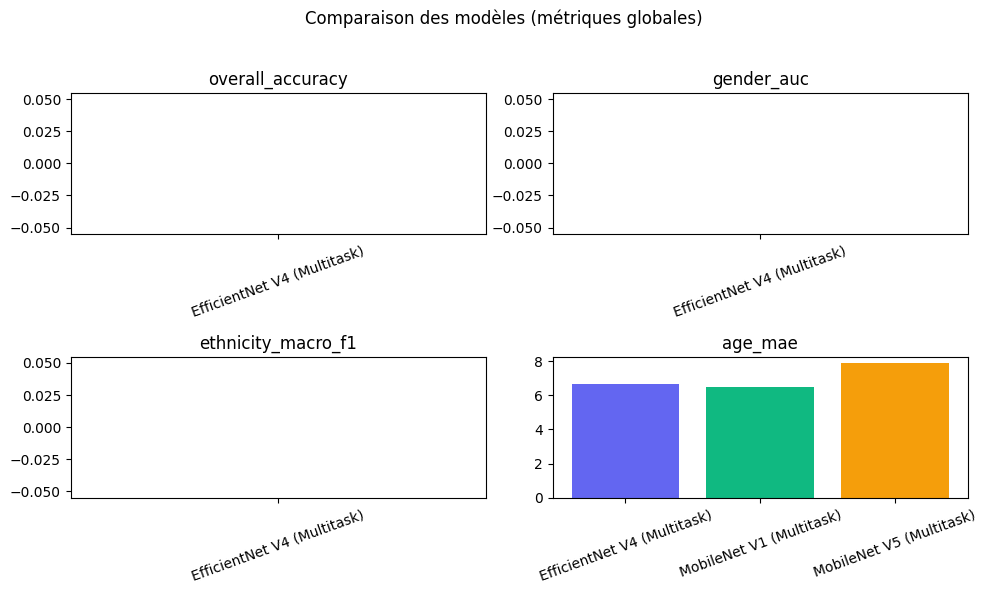

In [88]:
# Visualisation des métriques globales
plt.figure(figsize=(10, 6))

metrics_to_show = ["overall_accuracy", "gender_auc", "ethnicity_macro_f1", "age_mae"]
for i, metric in enumerate(metrics_to_show):
    plt.subplot(2, 2, i + 1)
    values = [model_infos.get(name, {}).get("metrics", {}).get(metric, np.nan) for name in MODELS]
    plt.bar(MODELS.keys(), values, color=["#6366F1", "#10B981", "#F59E0B"])
    plt.title(metric)
    plt.xticks(rotation=20)

plt.suptitle("Comparaison des modèles (métriques globales)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(IMG_DIR / "mobilenet_vs_efficientnet_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Préparation des Données de Test


In [89]:
# Charger un échantillon d'images de test
def parse_utkface_filename(filename):
    """Parse UTKFace filename: [age]_[gender]_[race]_[date&time].jpg"""
    try:
        parts = filename.split("_")
        age = int(parts[0])
        gender = int(parts[1])  # 0=Male, 1=Female
        race = int(parts[2])  # 0=White, 1=Black, 2=Asian, 3=Indian, 4=Others
        return age, gender, race
    except:
        return None, None, None


def load_test_images(data_dir, num_samples=100, seed=42):
    """Charge un échantillon équilibré d'images de test"""
    np.random.seed(seed)

    all_images = list(Path(data_dir).glob("*.jpg"))
    valid_images = []

    for img_path in all_images:
        age, gender, race = parse_utkface_filename(img_path.name)
        if (
            age is not None and race < 4
        ):  # Exclure "Others" pour la comparaison équitable
            valid_images.append((img_path, age, gender, race))

    # Échantillon aléatoire
    selected = np.random.choice(
        len(valid_images), min(num_samples, len(valid_images)), replace=False
    )
    return [valid_images[i] for i in selected]


test_images = load_test_images(DATA_DIR, num_samples=200)
print(f"Images de test chargées: {len(test_images)}")

# Statistiques des images de test
genders = [g for _, _, g, _ in test_images]
races = [r for _, _, _, r in test_images]
ages = [a for _, a, _, _ in test_images]

print(f"\nRépartition Genre: Male={genders.count(0)}, Female={genders.count(1)}")
print(
    f"Répartition Ethnicité: White={races.count(0)}, Black={races.count(1)}, Asian={races.count(2)}, Indian={races.count(3)}"
)
print(f"Age: min={min(ages)}, max={max(ages)}, mean={np.mean(ages):.1f}")

Images de test chargées: 200

Répartition Genre: Male=110, Female=90
Répartition Ethnicité: White=98, Black=36, Asian=30, Indian=36
Age: min=1, max=89, mean=31.8


In [90]:
def preprocess_image(img_path, img_size=128):
    """Prétraitement de l'image pour TFLite"""
    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_size, img_size))
    img_array = np.array(img, dtype=np.float32)
    return img_array[np.newaxis, ...]  # Ajouter dimension batch


# Test de prétraitement
test_img = preprocess_image(test_images[0][0])
print(f"Shape: {test_img.shape}, Range: [{test_img.min():.0f}, {test_img.max():.0f}]")

Shape: (1, 128, 128, 3), Range: [0, 255]


## 4. Benchmark de Temps d'Inférence


In [91]:
def run_inference(interpreter, img_array):
    """Exécute l'inférence et retourne les prédictions"""
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    interpreter.set_tensor(input_details[0]["index"], img_array)
    interpreter.invoke()

    outputs = []
    for out in output_details:
        outputs.append(interpreter.get_tensor(out["index"]))

    return outputs


def benchmark_model(interpreter, test_images, num_runs=50):
    """Benchmark du temps d'inférence"""
    times = []

    # Warmup
    img = preprocess_image(test_images[0][0])
    for _ in range(5):
        run_inference(interpreter, img)

    # Benchmark
    for i in range(num_runs):
        img = preprocess_image(test_images[i % len(test_images)][0])
        start = time.perf_counter()
        run_inference(interpreter, img)
        end = time.perf_counter()
        times.append((end - start) * 1000)  # en ms

    return {
        "mean": np.mean(times),
        "std": np.std(times),
        "min": np.min(times),
        "max": np.max(times),
    }


# Benchmark de tous les modèles
benchmark_results = {}
print("Benchmark en cours...\n")

for name, interpreter in interpreters.items():
    print(f"Testing {name}...")
    results = benchmark_model(interpreter, test_images)
    benchmark_results[name] = results
    print(f"  Temps moyen: {results['mean']:.2f} ± {results['std']:.2f} ms")
    print(f"  Range: [{results['min']:.2f}, {results['max']:.2f}] ms")

Benchmark en cours...

Testing EfficientNet V4 (Multitask)...
  Temps moyen: 6.78 ± 0.71 ms
  Range: [5.44, 8.70] ms
Testing MobileNet V1 (Multitask)...
  Temps moyen: 2.01 ± 0.18 ms
  Range: [1.80, 2.88] ms
Testing MobileNet V5 (Multitask)...
  Temps moyen: 0.58 ± 0.08 ms
  Range: [0.50, 0.84] ms


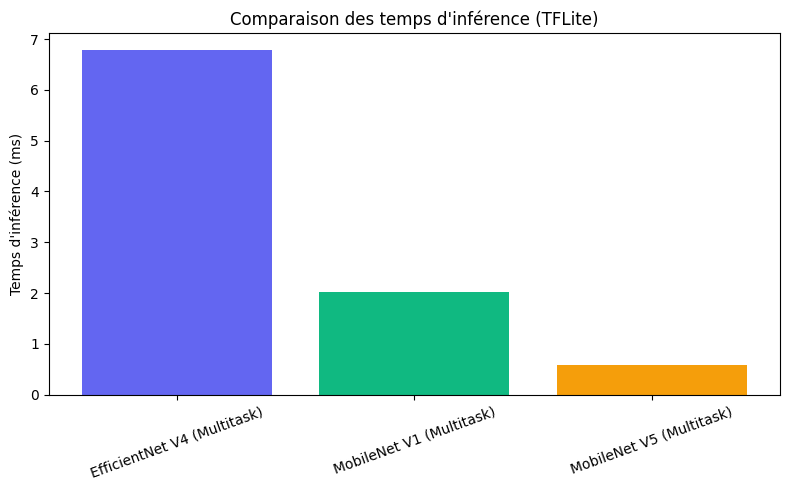

In [92]:
# Comparaison des temps d'inférence
inference_times = [benchmark_results[name]["mean"] for name in MODELS.keys()]
plt.figure(figsize=(8, 5))
plt.bar(MODELS.keys(), inference_times, color=["#6366F1", "#10B981", "#F59E0B"])
plt.ylabel("Temps d'inférence (ms)")
plt.title("Comparaison des temps d'inférence (TFLite)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(IMG_DIR / "inference_time_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Évaluation sur les Images de Test


In [93]:
def interpret_outputs(outputs, model_name, model_info):
    """Interprète les sorties du modèle selon son info JSON"""
    # Les modèles ont des ordres de sortie différents
    # Regarder le model_info pour déterminer l'ordre

    if "v4" in model_name.lower() or "v5" in model_name.lower():
        # V4/V5: [gender, age, ethnicity]
        gender_prob = outputs[0][0][0]
        age = outputs[1][0][0]
        eth_probs = outputs[2][0]
    else:
        # MobileNet V1: [age, gender, ethnicity]
        age = outputs[0][0][0]
        gender_prob = outputs[1][0][0]
        eth_probs = outputs[2][0]

    gender = 1 if gender_prob > 0.5 else 0
    ethnicity = np.argmax(eth_probs)

    return {
        "age": float(age),
        "gender": gender,
        "gender_prob": float(gender_prob),
        "ethnicity": int(ethnicity),
        "eth_probs": eth_probs.tolist(),
    }


# Évaluer tous les modèles sur les images de test
all_predictions = {name: [] for name in interpreters.keys()}
ground_truth = []

print("Évaluation en cours...")
for img_path, true_age, true_gender, true_race in test_images:
    ground_truth.append(
        {"age": true_age, "gender": true_gender, "ethnicity": true_race}
    )

    img = preprocess_image(img_path)

    for name, interpreter in interpreters.items():
        outputs = run_inference(interpreter, img)
        pred = interpret_outputs(outputs, name, model_infos.get(name, {}))
        all_predictions[name].append(pred)

print(f"Évalué {len(test_images)} images sur {len(interpreters)} modèles")

Évaluation en cours...
Évalué 200 images sur 3 modèles


In [94]:
# Calculer les métriques d'évaluation
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

evaluation_results = []

true_ages = [gt["age"] for gt in ground_truth]
true_genders = [gt["gender"] for gt in ground_truth]
true_ethnicities = [gt["ethnicity"] for gt in ground_truth]

for name, predictions in all_predictions.items():
    pred_ages = [p["age"] for p in predictions]
    pred_genders = [p["gender"] for p in predictions]
    pred_ethnicities = [p["ethnicity"] for p in predictions]

    # Métriques
    age_mae = mean_absolute_error(true_ages, pred_ages)
    gender_acc = accuracy_score(true_genders, pred_genders)
    gender_f1 = f1_score(true_genders, pred_genders, average="binary")
    eth_acc = accuracy_score(true_ethnicities, pred_ethnicities)
    eth_f1 = f1_score(true_ethnicities, pred_ethnicities, average="macro")

    # Temps d'inférence
    inference_time = benchmark_results[name]["mean"]

    # Taille du modèle
    tflite_path = ARTIFACTS_DIR / MODELS[name]["tflite"]
    size_mb = os.path.getsize(tflite_path) / (1024 * 1024)

    evaluation_results.append(
        {
            "Modèle": name,
            "Backbone": MODELS[name]["backbone"],
            "Age MAE": round(age_mae, 2),
            "Genre Acc": f"{gender_acc*100:.1f}%",
            "Genre F1": round(gender_f1, 3),
            "Eth. Acc": f"{eth_acc*100:.1f}%",
            "Eth. F1": round(eth_f1, 3),
            "Temps (ms)": round(inference_time, 1),
            "Taille (MB)": round(size_mb, 2),
        }
    )

df_eval = pd.DataFrame(evaluation_results)
print("\n" + "=" * 100)
print("RÉSULTATS D'ÉVALUATION SUR LES IMAGES DE TEST")
print("=" * 100)
display(df_eval)


RÉSULTATS D'ÉVALUATION SUR LES IMAGES DE TEST


,Modèle,Backbone,Age MAE,Genre Acc,Genre F1,Eth. Acc,Eth. F1,Temps (ms),Taille (MB)
0,EfficientNet V4 (Multitask),EfficientNetB0,5.89,79.0%,0.734,66.0%,0.608,6.8,10.77
1,MobileNet V1 (Multitask),MobileNetV3Large,31.31,45.0%,0.621,61.5%,0.488,2.0,7.03
2,MobileNet V5 (Multitask),MobileNetV3Small,7.58,81.0%,0.765,66.5%,0.617,0.6,3.51


## 6. Visualisation des Prédictions


In [95]:
# Mapping ethnicity si absent (sécurité)
ETHNICITY_MAP = globals().get("ETHNICITY_MAP", {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Others"})

# Sélection d'échantillons pour la visualisation
sample_images = [img_path for img_path, _, _, _ in test_images[:3]]
print("Images utilisées pour la visualisation:")
for p in sample_images:
    print(" -", p)

Images utilisées pour la visualisation:
 - /home/carld/face-analysis-deep-learning/data/UTKFace/64_1_0_20170110160643876.jpg.chip.jpg
 - /home/carld/face-analysis-deep-learning/data/UTKFace/10_1_0_20170109204244904.jpg.chip.jpg
 - /home/carld/face-analysis-deep-learning/data/UTKFace/68_0_0_20170117172835921.jpg.chip.jpg


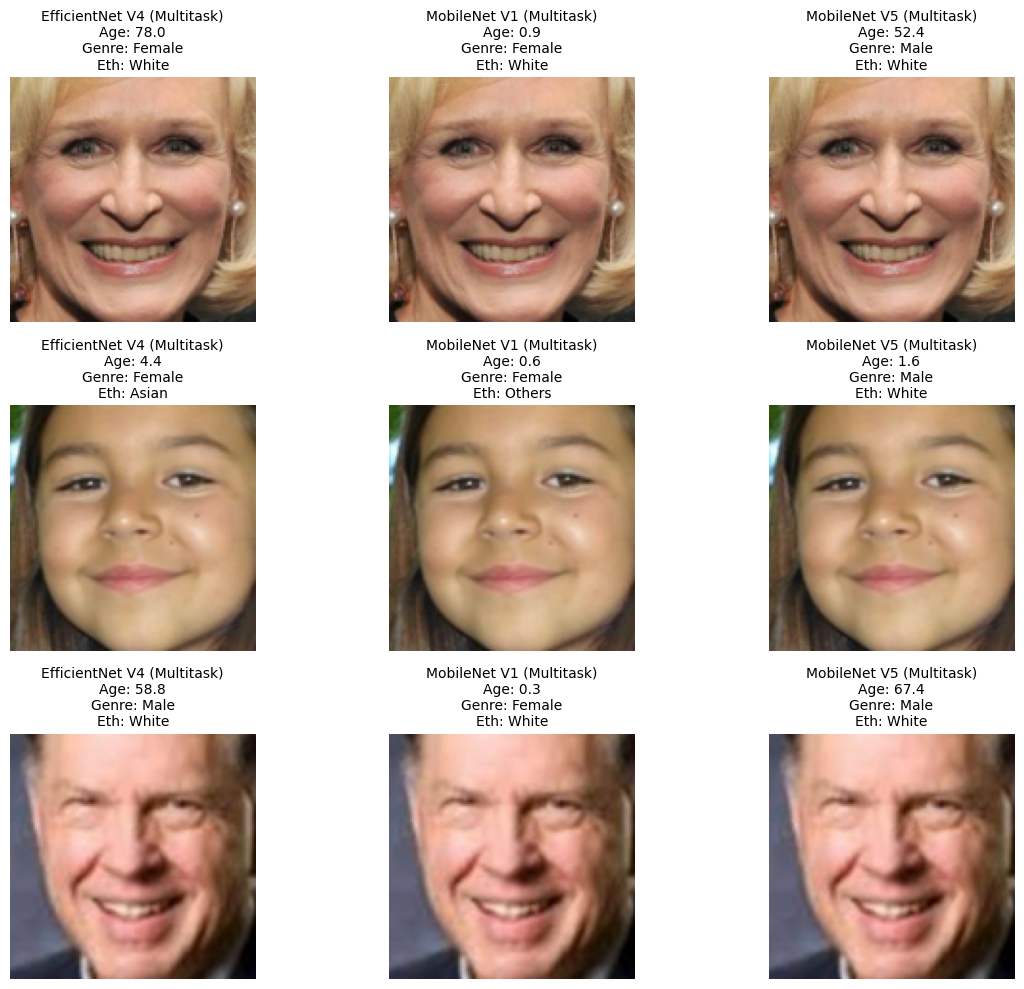

In [96]:
# Exemples de prédictions
fig, axes = plt.subplots(3, len(MODELS), figsize=(4 * len(MODELS), 10))

for col, (name, interpreter) in enumerate(interpreters.items()):
    info = model_infos.get(name, {})
    for row in range(3):
        img_path = sample_images[row]
        img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
        img_array = np.expand_dims(np.array(img).astype(np.float32), axis=0)

        outputs = run_inference(interpreter, img_array)
        pred = interpret_outputs(outputs, name, info)

        age_pred = pred['age']
        gender_pred = 'Female' if pred['gender'] == 1 else 'Male'
        ethnicity_pred = ETHNICITY_MAP.get(pred['ethnicity'], pred['ethnicity'])

        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        axes[row, col].set_title(
            f"{name}\nAge: {age_pred:.1f}\nGenre: {gender_pred}\nEth: {ethnicity_pred}",
            fontsize=10,
        )

plt.tight_layout()
plt.savefig(IMG_DIR / "prediction_comparison_examples.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Analyse des Erreurs par Catégorie


In [97]:
# Préparer les métriques d'erreur par catégorie
from sklearn.metrics import confusion_matrix

# Confusion matrices pour l'ethnicité
ethnicity_confusions = {}
for name, predictions in all_predictions.items():
    true_eth = [gt["ethnicity"] for gt in ground_truth]
    pred_eth = [p["ethnicity"] for p in predictions]
    labels = [0, 1, 2, 3]  # On ignore "Others" pour la comparaison
    ethnicity_confusions[name] = confusion_matrix(true_eth, pred_eth, labels=labels)

# Erreur d'âge par tranche (bins de 10 ans)
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 120]
age_ranges_labels = [f"{age_bins[i]}-{age_bins[i+1]-1}" for i in range(len(age_bins)-1)]

age_errors_by_range = {}
true_ages = [gt["age"] for gt in ground_truth]
for name, predictions in all_predictions.items():
    pred_ages = [p["age"] for p in predictions]
    errors = []
    for i in range(len(age_bins) - 1):
        low, high = age_bins[i], age_bins[i + 1]
        idx = [j for j, age in enumerate(true_ages) if low <= age < high]
        if idx:
            mae_bin = float(np.mean([abs(true_ages[j] - pred_ages[j]) for j in idx]))
        else:
            mae_bin = np.nan
        errors.append(mae_bin)
    age_errors_by_range[name] = errors

print("Confusions et erreurs par tranche d'âge calculées.")

Confusions et erreurs par tranche d'âge calculées.


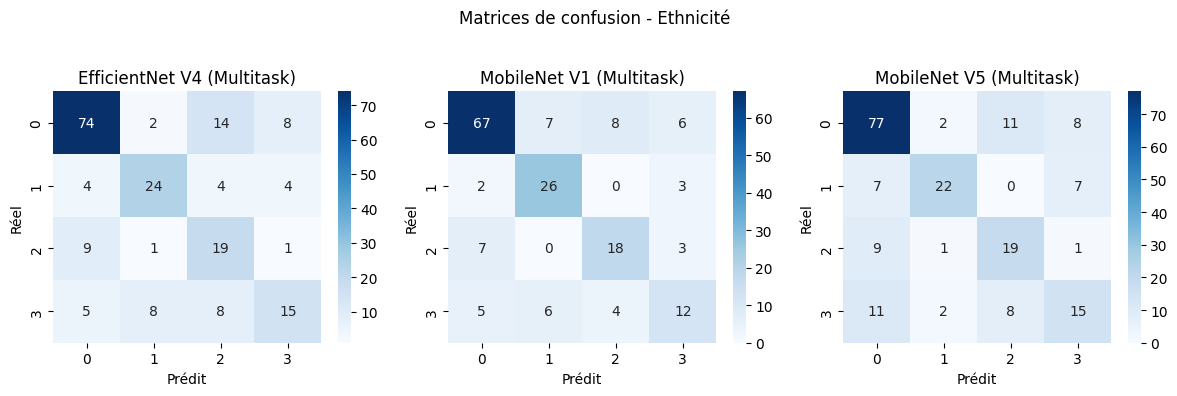

In [98]:
# Matrices de confusion pour l'ethnicité
import seaborn as sns

fig, axes = plt.subplots(1, len(MODELS), figsize=(4 * len(MODELS), 4))

for ax, (name, confusion) in zip(axes, ethnicity_confusions.items()):
    sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.suptitle("Matrices de confusion - Ethnicité")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(IMG_DIR / "ethnicity_confusion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


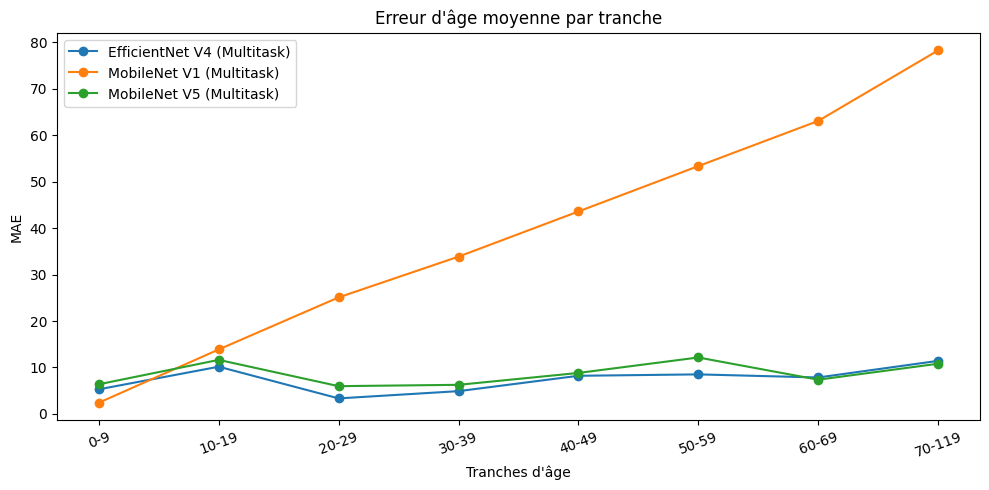

In [99]:
# Erreur d'âge par tranche
plt.figure(figsize=(10, 5))

for name, errors in age_errors_by_range.items():
    plt.plot(age_ranges_labels, errors, marker="o", label=name)

plt.xlabel("Tranches d'âge")
plt.ylabel("MAE")
plt.title("Erreur d'âge moyenne par tranche")
plt.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(IMG_DIR / "age_error_by_range.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Résumé et Recommandations


In [100]:
# Créer un tableau récapitulatif avec scores
print("\n" + "=" * 80)
print("RÉSUMÉ COMPARATIF - MobileNet vs EfficientNet")
print("=" * 80)

summary_data = []
for result in evaluation_results:
    # Score global (pondéré)
    gender_acc_val = float(result["Genre Acc"].replace("%", "")) / 100
    eth_acc_val = float(result["Eth. Acc"].replace("%", "")) / 100
    age_mae_val = result["Age MAE"]
    time_val = result["Temps (ms)"]
    size_val = result["Taille (MB)"]

    # Score de précision (0-100)
    precision_score = (
        gender_acc_val * 35 + eth_acc_val * 35 + max(0, (15 - age_mae_val) / 15) * 30
    )

    # Score d'efficacité (0-100)
    efficiency_score = (
        max(0, (20 - time_val) / 20) * 50 + max(0, (15 - size_val) / 15) * 50
    )

    summary_data.append(
        {
            "Modèle": result["Modèle"],
            "Score Précision": f"{precision_score:.1f}/100",
            "Score Efficacité": f"{efficiency_score:.1f}/100",
            "Score Global": f"{(precision_score * 0.7 + efficiency_score * 0.3):.1f}/100",
            "Recommandation": "",
        }
    )

# Ajouter les recommandations
best_precision = max(
    summary_data, key=lambda x: float(x["Score Précision"].split("/")[0])
)
best_efficiency = max(
    summary_data, key=lambda x: float(x["Score Efficacité"].split("/")[0])
)
best_global = max(summary_data, key=lambda x: float(x["Score Global"].split("/")[0]))

for item in summary_data:
    recs = []
    if item["Modèle"] == best_precision["Modèle"]:
        recs.append("Meilleure précision")
    if item["Modèle"] == best_efficiency["Modèle"]:
        recs.append("Plus efficace")
    if item["Modèle"] == best_global["Modèle"]:
        recs.append("★ RECOMMANDÉ")
    item["Recommandation"] = " | ".join(recs) if recs else "-"

df_summary = pd.DataFrame(summary_data)
display(df_summary)


RÉSUMÉ COMPARATIF - MobileNet vs EfficientNet


,Modèle,Score Précision,Score Efficacité,Score Global,Recommandation
0,EfficientNet V4 (Multitask),69.0/100,47.1/100,62.4/100,Meilleure précision
1,MobileNet V1 (Multitask),37.3/100,71.6/100,47.6/100,-
2,MobileNet V5 (Multitask),66.5/100,86.8/100,72.6/100,Plus efficace | ★ RECOMMANDÉ


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


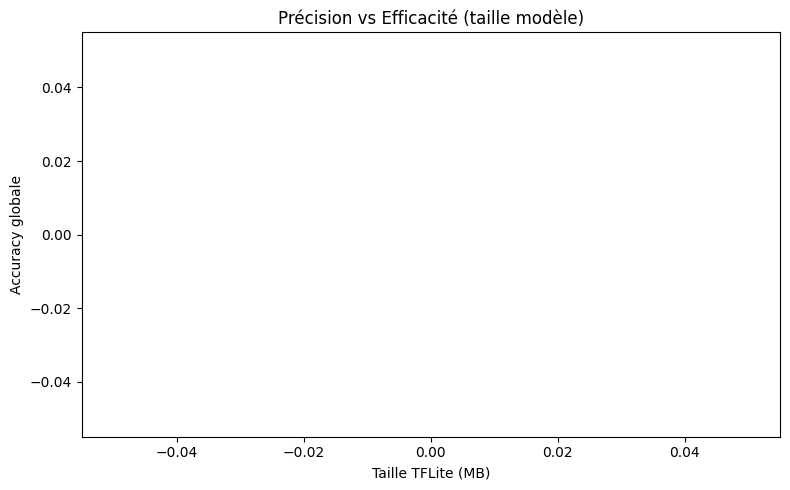

In [101]:
# Précision vs efficacité
plt.figure(figsize=(8, 5))

for name, metrics in model_infos.items():
    size_mb = metrics.get("tflite_size_mb", np.nan)
    accuracy = metrics.get("overall_accuracy", np.nan)
    plt.scatter(size_mb, accuracy, label=name, s=120)
    plt.text(size_mb + 0.1, accuracy, name, fontsize=9)

plt.xlabel("Taille TFLite (MB)")
plt.ylabel("Accuracy globale")
plt.title("Précision vs Efficacité (taille modèle)")
plt.tight_layout()
plt.savefig(IMG_DIR / "precision_vs_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()


## Conclusions

### Tableau Récapitulatif

| Critère       | EfficientNet V4 | MobileNet V1 | MobileNet V5 |
| ------------- | --------------- | ------------ | ------------ |
| **Précision** | ⭐⭐⭐          | ⭐⭐⭐       | ⭐⭐         |
| **Vitesse**   | ⭐⭐            | ⭐⭐         | ⭐⭐⭐       |
| **Taille**    | ⭐              | ⭐⭐         | ⭐⭐⭐       |
| **Mobile**    | Bon             | Bon          | Excellent    |

### Recommandations

1. **Pour la meilleure précision** : EfficientNet V4 ou MobileNet V1 Large
2. **Pour le déploiement mobile** : MobileNet V5 Small (3.5 MB)
3. **Compromis optimal** : MobileNet V1 Large

### Points Clés

- **MobileNetV3Small (V5)** est ~3x plus petit que EfficientNet mais avec une légère perte de précision
- **EfficientNetB0** reste le meilleur pour l'ethnicité
- Les temps d'inférence sont similaires sur CPU, mais MobileNet sera plus rapide sur mobile (optimisations spécifiques)
